In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from matplotlib.ticker import StrMethodFormatter
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
NBINS      = 35
MINSAMPLES = 50
LANDFRAC   = 0.5
NHOURBINS  = 8
REGIONS    = {'Ocean':'#539ED4','Land':'#D42028'}
REGISTRY   = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
              for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_moisture_term(rh):
    return kappa*(rh-rhmean)

def calc_instability_term(thetae,thetaestar):
    return thetae-gamma*thetaestar-thetac

def predict_from_sr_atm(moisture,instability):
    return np.maximum(np.expm1(lam*np.maximum(moisture,instability)**3),0.0)

def bin_2d(x,y,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges[0])-1,0,len(edges[0])-2)
    yi     = np.clip(np.digitize(y,edges[1])-1,0,len(edges[1])-2)
    shape  = (len(edges[0])-1,len(edges[1])-1)
    counts = np.zeros(shape)
    sums   = np.zeros(shape)
    np.add.at(counts,(xi,yi),1)
    np.add.at(sums,(xi,yi),z)
    return np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

def calc_local_hour_bin(hours,lon,shape,nbins=NHOURBINS):
    localhour = (hours[:,None,None]+lon[None,None,:]/15.0)%24
    return (np.broadcast_to(localhour,shape).ravel()//(24/nbins)).astype(int)

def bin_by_hour(hourbin,z,mask,nbins=NHOURBINS):
    counts = np.bincount(hourbin[mask],minlength=nbins)
    sums   = np.bincount(hourbin[mask],weights=z[mask],minlength=nbins)
    return sums/np.maximum(counts,1)

def calc_peak_hour(z,hourbin,mask,shape,nbins=NHOURBINS):
    ngrid     = shape[1]*shape[2]
    gridindex = np.broadcast_to(np.arange(ngrid),(shape[0],ngrid)).ravel()
    index     = hourbin[mask]*ngrid+gridindex[mask]
    counts    = np.bincount(index,minlength=nbins*ngrid).reshape(nbins,ngrid)
    sums      = np.bincount(index,weights=z[mask],minlength=nbins*ngrid).reshape(nbins,ngrid)
    composite = sums/np.maximum(counts,1)
    peak      = (np.argmax(composite,axis=0)+0.5)*24/nbins
    return np.where(composite.max(axis=0)>0,peak,np.nan).reshape(shape[1:])

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq']['constants'][name] for name in ['c3','c4','c5'])

lam    = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma  = c4*STATS['thetae_std']/STATS['thetaestar_std']
thetac = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa  = STATS['thetae_std']/STATS['rh_std']
rhmean = STATS['rh_mean']

constdf = pd.DataFrame([
    {'Constant':'$\\lambda$','Value':f'{lam:.3e}','Units':'1/K³'},
    {'Constant':'$\\gamma$','Value':f'{gamma:.3f}','Units':'dimensionless'},
    {'Constant':'$\\Theta_c$','Value':f'{thetac:.2f}','Units':'K'},
    {'Constant':'$\\kappa$','Value':f'{kappa:.3f}','Units':'K/%'},
    {'Constant':'$\\mu_\\mathrm{RH}$','Value':f'{rhmean:.2f}','Units':'%'}])
display(constdf.style.hide(axis='index'))

Constant,Value,Units
$\lambda$,1.106e-03,1/K³
$\gamma$,1.058,dimensionless
$\Theta_c$,-30.45,K
$\kappa_\mathrm{RH}$,0.414,K/%
$\mu_\mathrm{RH}$,68.07,%


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp     = ds['tp'].transpose('time','lat','lon').values.ravel()
with xr.open_dataset(os.path.join(PREDSDIR,f'sr_atm_eq_{SPLIT}_predictions.nc')) as ds:
    savedtp = ds['tp'].squeeze().transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals   = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
moisture    = calc_moisture_term(integrals['rh'])
instability = calc_instability_term(integrals['thetae'],integrals['thetaestar'])
predtp      = predict_from_sr_atm(moisture,instability)
finite      = np.isfinite(moisture)&np.isfinite(instability)&np.isfinite(tp)
print(f'Max difference from saved SR-ATM predictions: {np.nanmax(np.abs(predtp[finite]-savedtp[finite])):.2e} mm')

fracmap   = np.nanmean(np.where(finite,moisture>instability,np.nan).reshape(ntime,nlat,nlon),axis=0)
mlim,ilim = tuple(np.percentile(moisture[finite],[1,99])),tuple(np.percentile(instability[finite],[1,99]))
binedges   = (np.linspace(*mlim,NBINS+1),np.linspace(*ilim,NBINS+1))
bincenters = [0.5*(binedge[:-1]+binedge[1:]) for binedge in binedges]
binnedtp   = bin_2d(moisture[finite],instability[finite],tp[finite],binedges)
density    = np.log10(np.histogram2d(moisture[finite],instability[finite],bins=binedges)[0].clip(1))
m,i        = np.linspace(*mlim,200),np.linspace(*ilim,200)

Max difference from saved SR-ATM predictions: 8.53e-02 mm


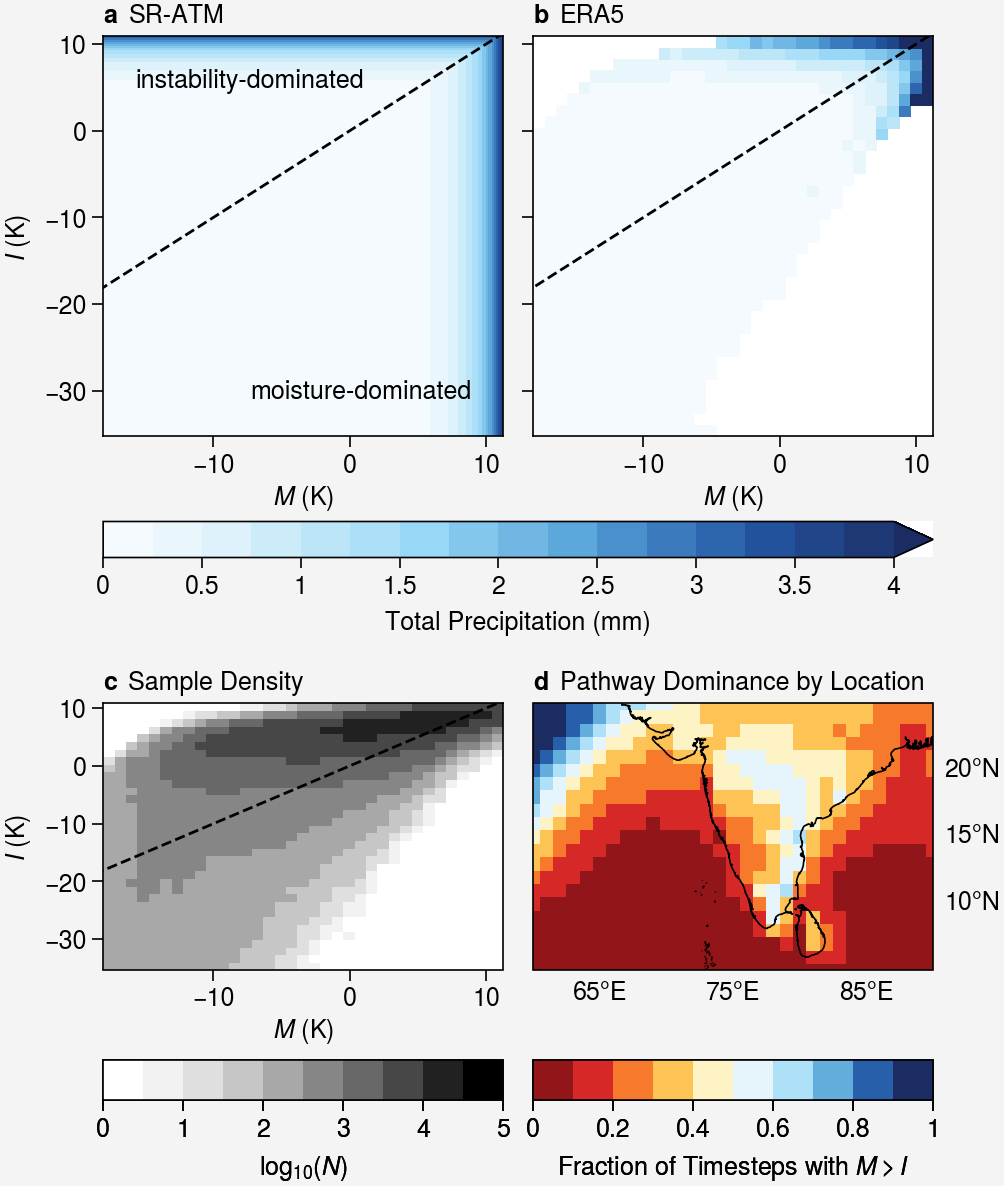

5.12


In [7]:
fig,axs = pplt.subplots([[1,2],[3,4]],refwidth=2,refheight=2,proj={4:'cyl'},share=False,wspace=1.2,hspace=8)
axs[2].set_box_aspect((LATRANGE[1]-LATRANGE[0])/(LONRANGE[1]-LONRANGE[0]))
m0 = axs[0].pcolormesh(m,i,predict_from_sr_atm(*np.meshgrid(m,i)),cmap='ColdHot_r',cmap_kw={'left':0.52},vmin=0,vmax=4,levels=18,extend='max')
m1 = axs[1].pcolormesh(bincenters[0],bincenters[1],binnedtp.T,cmap='ColdHot_r',cmap_kw={'left':0.52},vmin=0,vmax=4,levels=18,extend='max')
m2 = axs[2].pcolormesh(bincenters[0],bincenters[1],density.T,cmap='Grays',vmin=0,vmax=5)
m3 = axs[3].pcolormesh(lon,lat,fracmap,cmap='ColdHot_r',vmin=0,vmax=1)
for ax in axs[:3]:
    ax.plot([min(mlim[0],ilim[0]),max(mlim[1],ilim[1])],[min(mlim[0],ilim[0]),max(mlim[1],ilim[1])],'k--',linewidth=1)
axs[0].text(0.08,0.92,'instability-dominated',ha='left',va='top',transform=axs[0].transAxes)
axs[0].text(0.92,0.08,'moisture-dominated',ha='right',va='bottom',transform=axs[0].transAxes)
axs[:3].format(xlabel='$\\mathit{M}$ (K)',xlabelpad=2,xlim=mlim,ylim=ilim)
axs[0].format(title='SR-ATM',ylabel='$\\mathit{I}$ (K)')
axs[1].format(title='ERA5',yticklabels=[])
axs[2].format(title='Sample Density',ylabel='$\\mathit{I}$ (K)')
axs[3].format(title='Pathway Dominance by Location',coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',latlim=LATRANGE,latlines=[10,15,20],latlabels='r',grid=False)
axs[2].colorbar(m2,loc='b',label='log$_{10}$($\\mathit{N}$)')
axs[3].colorbar(m3,loc='b',ticks=0.2,label='Fraction of Timesteps with $\\mathit{M} > \\mathit{I}$')
fig.format(abc=True,titleloc='l')

fig.canvas.draw()
top    = [ax.get_position() for ax in axs[:2]]
bottom = [ax.get_position() for ax in axs[2:]]
middle = 0.5*(min(pos.y0 for pos in top)+max(pos.y1 for pos in bottom))
cax = fig.add_axes([top[0].x0,middle-0.09/fig.get_figheight()+0.15/fig.get_figheight(),top[1].x1-top[0].x0,0.18/fig.get_figheight()])
cb  = fig.colorbar(m0,cax=cax,orientation='horizontal',label='Total Precipitation (mm)',extend='max')
cb.ax.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
pplt.show()
fig.save('../figs/fig_4.jpg')
print(round(fig.get_figwidth(),2))

In [ ]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    hours = ds['time'].dt.hour.values
    lf    = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()
shape       = (ntime,nlat,nlon)
hourbin     = calc_local_hour_bin(hours,lon,shape)
hourcenters = (np.arange(NHOURBINS)+0.5)*24/NHOURBINS
regionmasks = {'Ocean':finite&(lf<LANDFRAC),'Land':finite&(lf>=LANDFRAC)}

In [ ]:
fig,axs = pplt.subplots(ncols=3,refwidth=2,refheight=2,share=False,wspace=3)
for region,color in REGIONS.items():
    mask     = regionmasks[region]
    meanm    = bin_by_hour(hourbin,moisture,mask)
    meani    = bin_by_hour(hourbin,instability,mask)
    axs[0].plot(np.append(meanm,meanm[0]),np.append(meani,meani[0]),color=color,linewidth=1,marker='o',markersize=3,label=region)
    for x,y,hour in zip(meanm,meani,hourcenters):
        axs[0].text(x,y,f' {hour:g}',color=color,fontsize=7,ha='left',va='bottom')
    axs[1].plot(hourcenters,bin_by_hour(hourbin,(moisture>instability).astype(float),mask),color=color,linewidth=1,marker='o',markersize=3,label=region)
    axs[2].plot(hourcenters,bin_by_hour(hourbin,tp,mask),color=color,marker='o',markersize=3,linestyle='none')
    axs[2].plot(hourcenters,bin_by_hour(hourbin,predtp,mask),color=color,linewidth=1)
means = np.array([[bin_by_hour(hourbin,term,regionmasks[region]) for term in (moisture,instability)] for region in REGIONS])
pad   = 0.1*np.ptp(means[:,:,:],axis=(0,2))+0.1
xlim  = (means[:,0].min()-pad[0],means[:,0].max()+pad[0])
ylim  = (means[:,1].min()-pad[1],means[:,1].max()+pad[1])
lims  = np.array([min(xlim[0],ylim[0]),max(xlim[1],ylim[1])])
axs[0].plot(lims,lims,'k--',linewidth=1)
axs[0].format(title='Diurnal Mean Trajectory',xlabel='$\\mathit{M}$ (K)',ylabel='$\\mathit{I}$ (K)',xlim=xlim,ylim=ylim,xreverse=False,yreverse=False)
axs[0].legend(loc='ul',ncols=1)
axs[1].format(title='Moisture Dominance',ylabel='Fraction with $\\mathit{M} > \\mathit{I}$')
for label,kwargs in [('ERA5',dict(marker='o',linestyle='none',markersize=3)),('SR-ATM',dict(linewidth=1))]:
    axs[2].plot([],[],color='black',label=label,**kwargs)
axs[2].legend(loc='ul',ncols=1)
axs[2].format(title='Diurnal Cycle of Precipitation',ylabel='Total Precipitation (mm)')
axs[1:].format(xlabel='Local Solar Time at Window Start (h)',xlim=(0,24),xticks=6)
axs.format(abc=True,titleloc='l')
pplt.show()
for region in REGIONS:
    mask = regionmasks[region]
    print(f'{region}: diurnal range of mean M = {np.ptp(bin_by_hour(hourbin,moisture,mask)):.2f} K, mean I = {np.ptp(bin_by_hour(hourbin,instability,mask)):.2f} K')

In [ ]:
fig,axs = pplt.subplots(ncols=2,proj='cyl',refwidth=2.5,wspace=1.5)
for ax,target,title in [(axs[0],tp,'ERA5'),(axs[1],predtp,'SR-ATM')]:
    m = ax.pcolormesh(lon,lat,calc_peak_hour(target,hourbin,finite,shape),cmap='twilight',vmin=0,vmax=24,levels=NHOURBINS)
    ax.format(title=f'{title} Local Hour of Peak Precipitation')
fig.colorbar(m,loc='b',ticks=3,label='Local Solar Time at Window Start (h)')
axs.format(coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',latlim=LATRANGE,latlines=[10,15,20],latlabels='r',grid=False,abc=True,titleloc='l')
pplt.show()